# Retinoid Chemistry: Marketing Claims vs Molecular Reality


This project is an investigation into the deeper chemistry behind claims pushed at us from tactically eye-catching bottles promising to perfect our skin. This notebook is intended as a widely accessible demonstration of the gap between potentially misleading marketing language and the molecular realities. Skincare is an industry which will remain in high demand due to the almost inescapable rise of skin issues and the popularity of anti-aging culture. There are a variety of relevant and useful vitamin A derivatives. This analysis, however, focuses primarily on four molecules central to the skincare conversion pathway illustrated below.

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw

molecules = {
    "Retinol (all-trans)": "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/CO)/C)/C",
    "Retinaldehyde (all-trans)": "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/C=O)/C)/C",
    "Tretinoin (all-trans retinoic acid)": "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/C(=O)O)/C)/C",
    "Isotretinoin (13-cis retinoic acid)": "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C\\C(=O)O)/C)/C",
}

mols = {name: Chem.MolFromSmiles(smi) for name, smi in molecules.items()}
names = list(mols.keys())

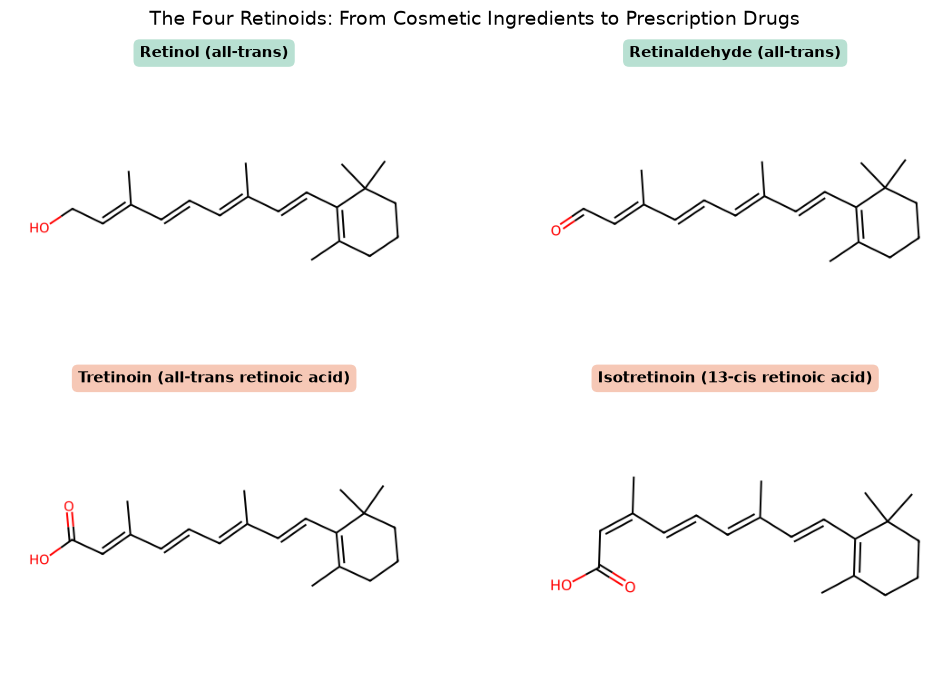

In [2]:
import matplotlib.pyplot as plt

colours = ["#B8E0D2", "#B8E0D2", "#F6C8B6", "#F6C8B6"]  # teal OTC, coral prescription

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, name, colour in zip(axes.flat, names, colours):
    ax.imshow(Draw.MolToImage(mols[name], size=(450, 320)))
    ax.set_title(name, fontsize=11, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.4", facecolor=colour, edgecolor="none"))
    ax.axis("off")

fig.suptitle("The Four Retinoids: From Cosmetic Ingredients to Prescription Drugs",
             fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig("four_molecules.png", dpi=150, bbox_inches="tight")
plt.show()

### The Retinoid Activation Ladder - Chemical Conversion Steps

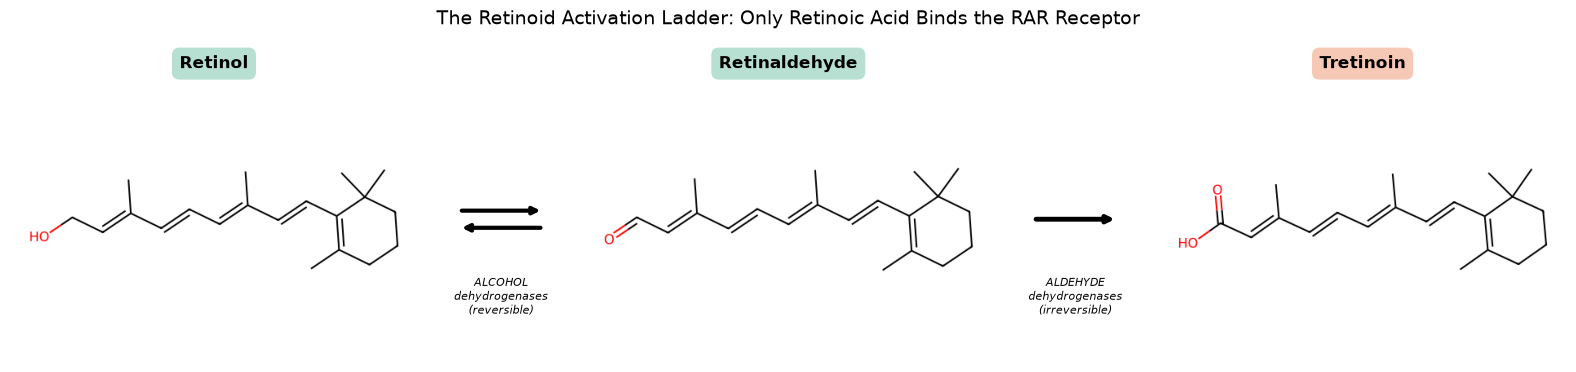

In [3]:
import matplotlib.pyplot as plt
from rdkit.Chem import Draw

names = list(mols.keys())
ladder = names[0:3]
enzymes = ["ALCOHOL\ndehydrogenases\n(reversible)", "ALDEHYDE\ndehydrogenases\n(irreversible)"]

# colour per molecule: cosmetic OTC in teal, prescription in coral
title_colours = ["#B8E0D2", "#B8E0D2", "#F6C8B6"]

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5),
                         gridspec_kw={"width_ratios": [4, 1, 4, 1, 4]})

mol_axes = [axes[0], axes[2], axes[4]]
arrow_axes = [axes[1], axes[3]]

for ax, name, colour in zip(mol_axes, ladder, title_colours):
    img = Draw.MolToImage(mols[name], size=(500, 350))
    ax.imshow(img)
    ax.set_title(name.split(" (")[0], fontsize=12, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.45", facecolor=colour,
                           edgecolor="none"))
    ax.axis("off")

for i, (ax, label) in enumerate(zip(arrow_axes, enzymes)):
    if i == 0:
        ax.annotate("", xy=(0.9, 0.53), xytext=(0.1, 0.53),
                    arrowprops=dict(arrowstyle="-|>", lw=3, color="black"))
        ax.annotate("", xy=(0.1, 0.47), xytext=(0.9, 0.47),
                    arrowprops=dict(arrowstyle="-|>", lw=3, color="black"))
    else:
        ax.annotate("", xy=(0.9, 0.5), xytext=(0.1, 0.5),
                    arrowprops=dict(arrowstyle="-|>", lw=3.5, color="black"))
    ax.text(0.5, 0.30, label, fontsize=8, ha="center", va="top", style="italic")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")

fig.suptitle("The Retinoid Activation Ladder: Only Retinoic Acid Binds the RAR Receptor",
             fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig("conversion_ladder.png", dpi=150, bbox_inches="tight")
plt.show()

The figure above illustrates the chemical conversion steps involved in producing the active chemical retinoic acid (marketed as tretinoin). The process is a two-step enzymatic oxidation: retinol (a primary alcohol) is first converted to retinaldehyde in a reversible step, which is then irreversibly oxidised to the all-trans retinoic acid molecule. The final active molecule may then bind to retinoic acid receptors (RARs) within the nuclei of skin cells of the epidermis. 

This sequence is notable because of the potency claims made on product labels. These claims can be misleading due to the inefficiencies associated with chemical conversion steps causing losses of material. For example, a product containing vitamin A in the form of retinol requires both conversion steps to produce the active molecule, so the yield of active retinoic acid from the applied retinol is lower than the label implies. 

In [4]:
info = {
    "Retinol (all-trans)": {"route": "topical", "status": "cosmetic (OTC)"},
    "Retinaldehyde (all-trans)": {"route": "topical", "status": "cosmetic (OTC)"},
    "Tretinoin (all-trans retinoic acid)": {"route": "topical", "status": "prescription"},
    "Isotretinoin (13-cis retinoic acid)": {"route": "oral", "status": "prescription"},
}

### Geometric Isomers: Cis/Trans Configurations 

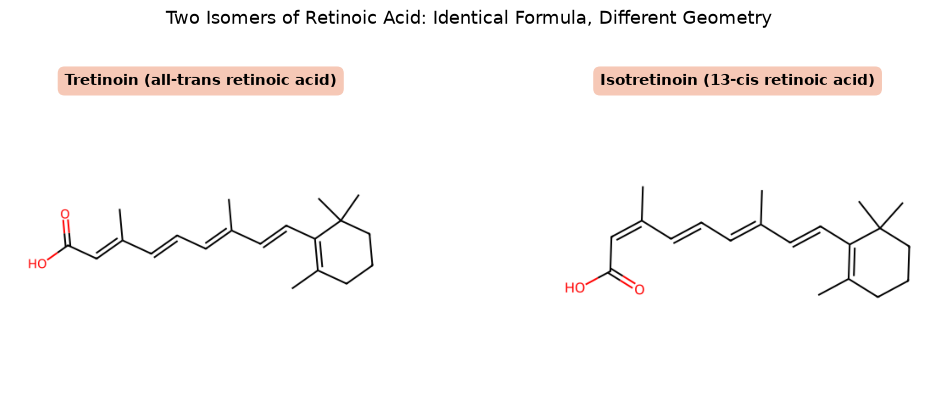

In [5]:
import matplotlib.pyplot as plt
from rdkit.Chem import Draw

pair = [names[2], names[3]]   # tretinoin, isotretinoin
imgs = [Draw.MolToImage(mols[n], size=(450, 350)) for n in pair]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, img, name in zip(axes, imgs, pair):
    ax.imshow(img)
    ax.set_title(name, fontsize=11, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.45", facecolor="#F6C8B6",
                           edgecolor="none"))
    ax.axis("off")

fig.suptitle("Two Isomers of Retinoic Acid: Identical Formula, Different Geometry",
             fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig("isomer_pair.png", dpi=150, bbox_inches="tight")
plt.show()

Tretinoin and isotretinoin are geometric isomers of one another, meaning that they share the same molecular formula but possess different spatial arrangements due to restricted rotation. Rotation is restricted about pi-bonds, and in isotretinoin this produces a visible "kink" at the carbon-13 double bond.

The table below displays the numerical descriptors of each molecule which do not factor in the crucial idea of geometry. The isomer pair possesses the same values within the table, causing them to appear identical. These values are unfit to be used alone for comparison as they are solely based on which atoms are connected. Even the rotatable bond count is identical, as it leaves out the C13 double bond amongst all other double bonds. 

Receptors and enzymes rely on precise three-dimensional geometry; shifting from a straight trans to a bent cis configuration directly alters how the molecule binds to nuclear receptors. 

##### Numerical Molecular Descriptors 

In [6]:
import pandas as pd
from rdkit.Chem import Descriptors

rows = []
for name, mol in mols.items():
    rows.append({
        "Molecule": name,
        "Delivery Route": info[name]["route"],
        "Status": info[name]["status"],
        "Mr": round(Descriptors.MolWt(mol), 1),
        "LogP": round(Descriptors.MolLogP(mol), 2),
        "TPSA": round(Descriptors.TPSA(mol), 1),
        "HBondDonors": Descriptors.NumHDonors(mol),
        "HBondAcceptors": Descriptors.NumHAcceptors(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol),
    })

df = pd.DataFrame(rows)
df

,Molecule,Delivery Route,Status,Mr,LogP,TPSA,HBondDonors,HBondAcceptors,RotatableBonds
0,Retinol (all-trans),topical,cosmetic (OTC),286.5,5.51,20.2,1,1,5
1,Retinaldehyde (all-trans),topical,cosmetic (OTC),284.4,5.72,17.1,0,1,5
2,Tretinoin (all-trans retinoic acid),topical,prescription,300.4,5.60,37.3,1,1,5
3,Isotretinoin (13-cis retinoic acid),oral,prescription,300.4,5.60,37.3,1,1,5


### Lipinski's Rule of Five

Lipinski's Rule of Five is a guideline widely used in drug discovery to help predict whether or not certain molecules will be orally bioavailable. In order for a molecule to be deemed suitable for oral use it must have no more than one violation of the following conditions:

1. No more than 5 hydrogen bond donors 
2. No more than 10 hydrogen bond acceptors 
3. Molecular mass (Mr) less than 500 daltons (Da)
4. Partition coefficient no greater than 5 

From the table we see that all four molecules have one violation of Lipinski's Rule of Five each: all display partition coefficients larger than 5.0.

In [7]:
lip = pd.DataFrame({
    "Molecule": df["Molecule"],
    "Condition 1": (df["HBondDonors"] <= 5).map({True: "\u2713", False: "\u2717"}),
    "Condition 2": (df["HBondAcceptors"] <= 10).map({True: "\u2713", False: "\u2717"}),
    "Condition 3": (df["Mr"] < 500).map({True: "\u2713", False: "\u2717"}),
    "Condition 4": (df["LogP"] <= 5).map({True: "\u2713", False: "\u2717"}),
})
lip

,Molecule,Condition 1,Condition 2,Condition 3,Condition 4
0,Retinol (all-trans),✓,✓,✓,✗
1,Retinaldehyde (all-trans),✓,✓,✓,✗
2,Tretinoin (all-trans retinoic acid),✓,✓,✓,✗
3,Isotretinoin (13-cis retinoic acid),✓,✓,✓,✗


Retinoic acid is prescription-only and therefore cannot be sold by cosmetic companies in its active form. Retinol and retinaldehyde are the strongest retinoids permitted in cosmetics; these forms, as shown above, are substantially weaker in comparison to the acid itself. The chemical losses suffered through one or more conversion steps cause these products to facilitate the delivery of less retinoic acid to a user's face. Products are nonetheless marketed with strong efficacy language suggesting a similar level of benefit to products such as prescription tretinoin. The two prescription forms differ in application: isotretinoin is an oral medication delivering a systemic treatment for severe or widespread acne. Tretinoin, however, is a topical treatment delivered to localised regions where the user suffers from acne.  

### Prodrugs: Engineering Around the Prescription Wall

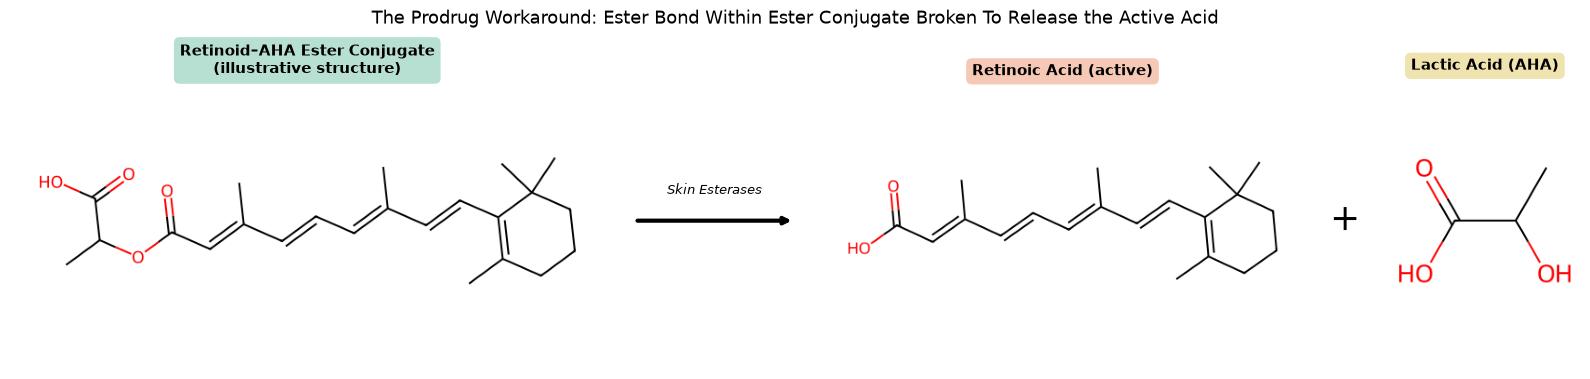

In [8]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw

ester_smiles = "CC1=C(C(CCC1)(C)C)/C=C/C(=C/C=C/C(=C/C(=O)OC(C)C(=O)O)/C)/C"
ester_mol = Chem.MolFromSmiles(ester_smiles)
acid_mol = Chem.MolFromSmiles(molecules["Tretinoin (all-trans retinoic acid)"])
lactic_mol = Chem.MolFromSmiles("CC(O)C(=O)O")

fig, axes = plt.subplots(1, 5, figsize=(16, 3.6),
                         gridspec_kw={"width_ratios": [5, 1.6, 4, 0.5, 1.6]})

panels = [
    (axes[0], ester_mol, "Retinoid\u2013AHA Ester Conjugate\n(illustrative structure)", "#B8E0D2", (640, 300)),
    (axes[2], acid_mol,  "Retinoic Acid (active)",  "#F6C8B6", (520, 300)),
    (axes[4], lactic_mol,"Lactic Acid (AHA)",       "#EFE3B0", (200, 300)),
]

for ax, mol, label, colour, size in panels:
    ax.imshow(Draw.MolToImage(mol, size=size))
    ax.set_title(label, fontsize=10.5, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.4", facecolor=colour, edgecolor="none"))
    ax.axis("off")

# arrow panel with label sitting on the arrow
axes[1].annotate("", xy=(0.92, 0.5), xytext=(0.08, 0.5),
                 arrowprops=dict(arrowstyle="-|>", lw=3, color="black"))
axes[1].text(0.5, 0.58, "Skin Esterases", fontsize=9, ha="center",
             va="bottom", style="italic")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1); axes[1].axis("off")

# plus panel
axes[3].text(0.5, 0.5, "+", fontsize=26, ha="center", va="center")
axes[3].set_xlim(0, 1); axes[3].set_ylim(0, 1); axes[3].axis("off")

fig.suptitle("The Prodrug Workaround: Ester Bond Within Ester Conjugate Broken To Release the Active Acid",
             fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig("ester_prodrug.png", dpi=150, bbox_inches="tight")
plt.show()

A prodrug is a relatively inactive molecule designed to be converted into an active medical drug when applied or ingested. In this case, a less active vitamin A derivative converts to the active form via enzymatic cleavage. 

The starting prodrug molecule contains retinoic acid chemically bonded to lactic acid via an ester bond. This compound is not retinoic acid on paper and therefore successfully dodges the prescription restriction and is able to be sold as a cosmetic product. The image above is simply a demonstrative illustration of the strategy and does not accurately describe commercial versions with a patent.

Esterases, enzymes naturally present in skin that break ester bonds, cleave the link. Two active ingredients are released from one molecule: the lactic acid (AHA) exfoliant and retinoic acid (the active and usually prescription-only retinoid). 

This is more effective than the use of retinol despite also involving a conversion step. The two enzymatic oxidations involved in the activation of retinol are significantly more wasteful and therefore lower-yielding than the singular hydrolysis. Ester hydrolysis, involved in the prodrug approach, is a single and efficient enzymatic cleavage, so a larger proportion of the applied molecule is converted into the active retinoic acid.   

## What the Trials Actually Show
##### The preceding sections argued from structure alone. This section compares those predictions against published clinical and molecular data.



**Kafi et al. (2007)**: randomised, double-blind, vehicle-controlled trial

- 36 participants, mean age 87, from two senior citizen facilities
- 0.4% retinol lotion vs its vehicle, opposite arms, up to 3× weekly for 24 weeks
- Outcomes: severity scored 0–9 (0 = none, 9 = most severe) by blinded dermatologists, plus skin biopsies
- Fine wrinkling change: −1.64 with retinol vs −0.08 with vehicle (P<.001) - negative values indicate improvement
- Retinol also increased glycosaminoglycan expression (P=.02, n=6) and procollagen I (P=.049, n=4)
- Authors attribute the wrinkle improvement to glycosaminoglycan retaining water and increased collagen production

#### Receptor Activation:


**Separate bioactivity experiment** — the source of the figure below

- 5 healthy, non-geriatric volunteers (distinct from the 36-person main trial)
- Four treatments applied to buttock skin: 0.4% retinol lotion, its vehicle, 0.1% retinoic acid in ethanol-propylene glycol (positive control), and ethanol-propylene glycol alone (negative control)
- One biopsy per treatment site, taken after 24 hours
- CRABPII mRNA quantified: CRABPII is induced dose-dependently by retinoids, so acts as an indicator of retinoid activity
- Reported result: authors conclude that the 0.4% retinol penetrates skin and produces retinoid-induced molecular changes, describing the response as comparable to 0.1% retinoic acid
- The figure below shows retinoic acid producing a larger response (~3.9-fold vs ~2.8-fold) despite being applied at a quarter of the concentration

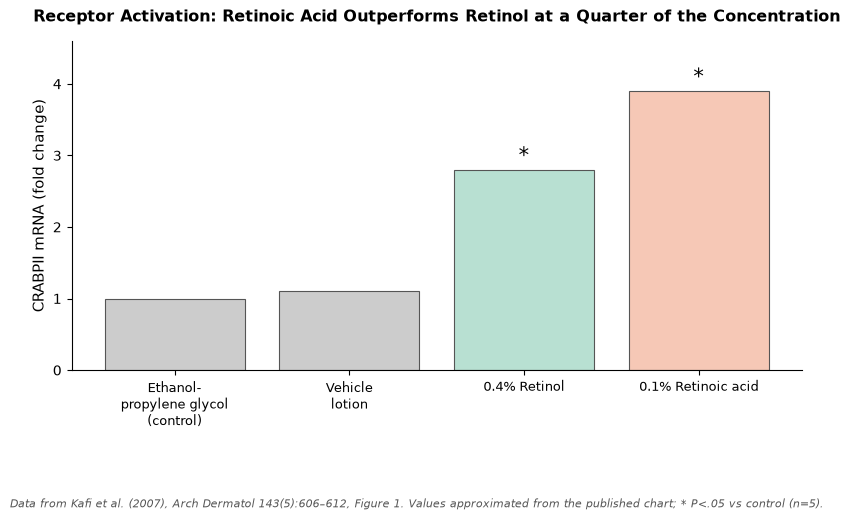

In [11]:
import matplotlib.pyplot as plt

conditions = ["Ethanol-\npropylene glycol\n(control)", "Vehicle\nlotion",
              "0.4% Retinol", "0.1% Retinoic acid"]
fold_change = [1.0, 1.1, 2.8, 3.9]
bar_colours = ["#CCCCCC", "#CCCCCC", "#B8E0D2", "#F6C8B6"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(conditions, fold_change, color=bar_colours, edgecolor="#555555", linewidth=0.8)

# significance markers
for bar, sig in zip(bars, [False, False, True, True]):
    if sig:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.12, "*",
                ha="center", fontsize=15)

ax.set_ylabel("CRABPII mRNA (fold change)", fontsize=11)
ax.set_title("Receptor Activation: Retinoic Acid Outperforms Retinol at a Quarter of the Concentration",
             fontsize=11.5, fontweight="bold", pad=14)
ax.set_ylim(0, 4.6)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelsize=9)

fig.text(0.5, -0.14,
         "Data from Kafi et al. (2007), Arch Dermatol 143(5):606\u2013612, Figure 1. "
         "Values approximated from the published chart; * P<.05 vs control (n=5).",
         ha="center", fontsize=8, style="italic", color="#555555")

plt.tight_layout()
plt.savefig("receptor_activation.png", dpi=150, bbox_inches="tight")
plt.show()

The y-axis of the figure above, 'fold change', describes how many times higher the CRABPII mRNA level was compared with untreated skin, which is set to 1. CRABPII is a protein used as a biomarker of retinoic acid activity that binds all-trans-retinoic acid within skin cells and transfers it to nuclear retinoic acid receptors (RARs). The control group already has a baseline mRNA level, so it is the increase in production of CRABPII mRNA which is measured. A spike will suggest that the retinoic acid signalling pathway is actively initiating gene transcription.  

Although early receptor activation is a meaningful indicator of retinoid activity, there are certain caveats involved as this is not a fully comprehensive experimental measure. For example, the biopsies were taken 24 hours after application which fails to account for potential improvements in the skin over time or any adverse effects such as irritation. 
Another limitation is the small sample size limited to 5 individuals within a separate bioactivity study. The samples were also taken from buttock skin rather than facial skin, which is thinner and more sensitive.
Additionally, this trial was conducted with non-elderly and healthy individuals unlike the main trial volunteers who had a mean age of 87 and were selected from a care home. The bar values have been approximated from the published figure and so are solely intended to act as an illustration of the visible proportions between groups.

### References 

1. Kafi R, Kwak HSR, Schumacher WE, et al. Improvement of Naturally Aged Skin With Vitamin A (Retinol). *Arch Dermatol.* 2007;143(5):606–612. doi:10.1001/archderm.143.5.606
